# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
#importação da base .csv e criação do dataframe
df = pd.read_csv('CHURN_CREDIT_MOD14_PART2.csv', delimiter=',')

df.head(5)

,customerID,Gender,Elderly,Married,Dependents,Time_as_Client,PhoneService,Internet_Service,Security_Service,Suport,StreamingTV,Contract_Type,PaymentMethod,Monthly_Payment,Total_Paid,Churn
0,7590-VHVEG,F,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,M,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,M,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,M,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),65.61,1840.75,No
4,8191-XWSZG,F,0,No,No,52,Yes,NO,No internet service,No internet service,No internet service,One year,Mailed check,65.61,1022.95,No


In [3]:
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No':0})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2488 entries, 0 to 2487
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2488 non-null   object 
 1   Gender            2488 non-null   object 
 2   Elderly           2488 non-null   int64  
 3   Married           2488 non-null   object 
 4   Dependents        2488 non-null   object 
 5   Time_as_Client    2488 non-null   int64  
 6   PhoneService      2488 non-null   object 
 7   Internet_Service  2488 non-null   object 
 8   Security_Service  2488 non-null   object 
 9   Suport            2488 non-null   object 
 10  StreamingTV       2488 non-null   object 
 11  Contract_Type     2488 non-null   object 
 12  PaymentMethod     2488 non-null   object 
 13  Monthly_Payment   2488 non-null   float64
 14  Total_Paid        2488 non-null   float64
 15  Churn             2488 non-null   object 
 16  Churn_Num         2488 non-null   int64  


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

In [4]:
# descritivo das variaveis quantitativas
df.describe()

,Elderly,Time_as_Client,Monthly_Payment,Total_Paid,Churn_Num
count,2488.000000,2488.000000,2488.00000,2488.000000,2488.000000
mean,0.161576,32.352090,65.60787,2290.087178,0.260048
std,0.368135,24.636885,27.98470,2264.585643,0.438749
min,0.000000,0.000000,18.40000,18.800000,0.000000
25%,0.000000,8.000000,45.40000,402.337500,0.000000
50%,0.000000,29.000000,65.61000,1402.900000,0.000000
75%,0.000000,56.000000,87.71250,3867.162500,1.000000
max,1.000000,72.000000,118.65000,8564.750000,1.000000


B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

* a variavel Total_Paid possui um alto desvio padrão e a media e mediana diferem bastante, a diferença do quartil superior para o valor maximo tambem é grande
* a variavel time_as_client tambem possui diferenças entre media e mediana e alto desvio padrão, junto com diferença de valor max e min
* a variavel Monthly_Payment possui uma distancia grande entre valor max e min, alem de um desvio medio alto

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

### tempo como cliente possui uma curva de aumento ou diminuição?

In [5]:
#histograma de time as client
px.histogram(df, x='Time_as_Client',
             barmode='relative', 
             title='Tempo como cliente',
             
            )

- insight: temos um alto nivel de churn a partir do quarto mês de adesão, tem uma tendencia estavel a partir do 35 ao 59 com baixa variação, e vem a diminuir a partir do 60 mês

### Os valores de mensalidade se comportam de forma equilibrada?

In [6]:
#histograma de Monthly Payment
px.histogram(df, x='Monthly_Payment', barmode='relative', title='Monthly Payment')

Insight: percebemos uma grande quantidade de clientes então agrupados em torno dos valors de 65 - 69.99

### Quantos clientes idosos ?

In [7]:
# contagem de clientes Elderly
contagem_elder = df['Elderly'].value_counts()

#percentual de clientes elderly
percentual_elder = (contagem_elder / contagem_elder.sum()) * 100

#juntando um DF de contagem 
dadosElder = pd.DataFrame({'Elderly' : contagem_elder.index,
                           'Contagem' : contagem_elder.values,
                           'Percentual' : percentual_elder.values,
                          })

#grafico de barras 
fig = px.bar(dadosElder, x='Elderly', y='Contagem', title='Clientes idosos - Elderly')
fig.show()

Insight: temos uma contagem baixa de clientes idosos, o que pode indicar irrelavancias de corpotamento para o padrão se considerarmos este grupo

### Qual percentual de Churn?

In [8]:
# percentual de churn
contagem_churn = df['Churn'].value_counts()
Percentual_Churn = (contagem_churn / contagem_churn.sum()) * 100

#df de Churn para grafico
dados_churn = pd.DataFrame({'Churn' : contagem_churn.index,
                            'percentual' : Percentual_Churn.values})

# grafico de barras de Churn
fig = px.bar(dados_churn, x='Churn', y='percentual', title='Churn Percentual')
fig.show()


Insight: Churn sendo o principal variavel a ser analise, vemos que mais de 70% dos nossos clientes estão propoensos ao churn

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [9]:
#boxplot para visualizar possivel outlier
fig = px.box(df, y='Total_Paid', points='all', title='BoxPlot - Total Paid')
fig.show()
             

### metodos de pagamentos geram corpoatamentos diferentes?

In [10]:
# definição dos putliers pelo IQR para melhor visualzação
Q1 = df['Total_Paid'].quantile(0.25) # define quartil inferior
Q3 = df['Total_Paid'].quantile(0.75) # define quartil superior
IQR = Q3 - Q1 # calcula o IQR

limite_inferior = Q1 - 1.5 * IQR # define limite inferior aceitavel
limite_superior = Q3 + 1.5 * IQR # define limite superior aceitavel

outliers = df[(df['Total_Paid'] < limite_inferior) | (df['Total_Paid'] > limite_superior)] #defino o que é outlier

print(f"Limite inferior: {limite_inferior}")
print(f"Limite superior: {limite_superior}")
print(f"Número de outliers: {len(outliers)}")


Limite inferior: -4794.9
Limite superior: 9064.4
Número de outliers: 0


In [11]:
#boxplot para visualizar possivel outlier
fig = px.box(df, y='Time_as_Client', points='all', title='BoxPlot - Time as Client')
fig.show()

In [12]:
#boxplot para visualizar possivel outlier
fig = px.box(df, y='Monthly_Payment', points='all', title='BoxPlot - Monthly Payment')
fig.show()

* Aqui percebemos que não posuimos outliers, mas sim uma dispersão muito irregular dos dados na parte superior, o que pode indicar contratos premium (com muitos beneficios) e que perduram por um longo periodo e como percebemos o Churn ocorre com frequencia nos primeiros meses, o que indica que clientes que passam dos primeiros meses costumam ficar por um tempo longo. por isso opto por manter os dados em sua forma sem padronização de outliers para maior precisão da analise.

# Analise Bivariada

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.

Insights e questionametos
- Homens são mais propensos ao Churn, do que mulheres?
- solteiros tem mais probabilidade ao churn?
- a variedade de serviço fornecidos ou não fornecidos, influencião o corportamento dos clientes?
- Quais os tipos de contranto propensos ao churn?
- Quais metodos de pagamento são mais propoensos ao churn?

### Homens são mais propensos ao Churn, do que mulheres?

In [13]:
# histrograma relação churn com gender
fig = px.histogram(df, x='Churn', color='Gender', barmode='stack')

#layout px
fig.update_layout(title= 'Relação entre Genero e Churn',
                  yaxis_title= 'Contagem',
                  xaxis_title='Churn'
                 )
fig.show()

Insight: é possivel perceber que homenes e mulheres tem uma relação muito parecida ao churn o que indica que há variaveis melhores para agirmos e trazer ganhos maioress

### solteiros tem mais probabilidade ao churn?

In [14]:
# histrograma relação churn com maried
fig = px.histogram(df, x='Churn', color='Married', barmode='stack')

#layout px
fig.update_layout(title= 'Relação entre estado Civil e Churn',
                  yaxis_title= 'Contagem',
                  xaxis_title='Churn'
                 )
fig.show()

insight: percebemos que solteiros possum a proximada o dobro de chances de aderirem ao churn, mas ainda assim não é um grupo grande para uma atividade efetiva

### À variedade de serviços de internet e relacionados fornecidos ou não, influenciam o comportamento dos clientes?

In [15]:
# definição das colunas de interesse
services = ['PhoneService','Internet_Service', 'Security_Service', 'Suport', 'StreamingTV', 'Churn_Num']

#contagem de serviços ativos
df['Qtd_serv_ativo'] = (df[services] !='No').sum(axis=1)

# calculo da taxa de churn pela quantidades de serviços
df_qtd_churn = (df.groupby('Qtd_serv_ativo')['Churn_Num'].mean().reset_index(name='Taxa_Churn'))
df_qtd_churn['Taxa_Churn'] = (df_qtd_churn['Taxa_Churn']*100).astype(int) # calcula taxa % e torna em numero intero para visualização

df_qtd_churn.head(10)

,Qtd_serv_ativo,Taxa_Churn
0,2,44
1,3,47
2,4,36
3,5,15
4,6,7


In [16]:
# renomeando a rotulos para maior clareza
df_qtd_churn['Qtd_serv_ativo'] = df_qtd_churn['Qtd_serv_ativo'].astype(str) + ' Serviços'

# grafico de barras horizontais
fig = px.bar(df_qtd_churn, 
             x ='Taxa_Churn',
             y = 'Qtd_serv_ativo',
             orientation = 'h',
             color='Taxa_Churn',
             color_continuous_scale='reds',
             title = 'Taxa Churn por Quantidade de Produtos'
            )
# formatação do grafico
fig.update_layout(
    xaxis_title='Taxa de Churn (%)',
    yaxis_title='Quantidade de Serviços',
    showlegend=False)

fig.show()    

insight: percebe-se que a quantidade de produtos influencia sim a taxa de churn, e com o número de produtos oferecidos o pior caso é clientes que utilizam 3 produtos, que chega a 47% de Churn srguido de perto por 2 serviços oferecidos com 44%. porem necessita de uma analise mais profunda para tras resultados mais concretos dos motivos desses altos indicese aonde especificamente eles se encontram.

 ### Quais os tipos de contranto propensos ao churn?

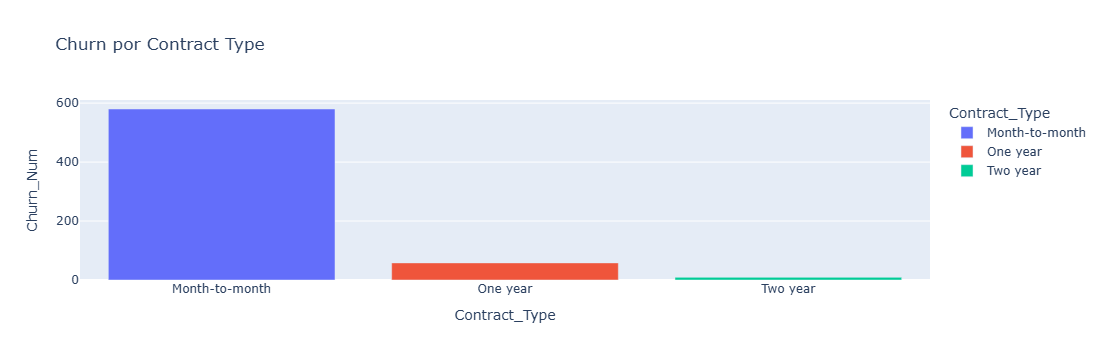

In [19]:
# barras sobre churn por tipo de 
churn_method = df.groupby('Contract_Type')['Churn_Num'].sum().reset_index()

fig = px.bar(data_frame = churn_method, x = 'Contract_Type', y ='Churn_Num',
             title = 'Churn por Contract Type',
             color='Contract_Type')
fig.show()

Insight: Percebese que clientes com o contrato no modo month-to-month são os principais ocasioandores do churn

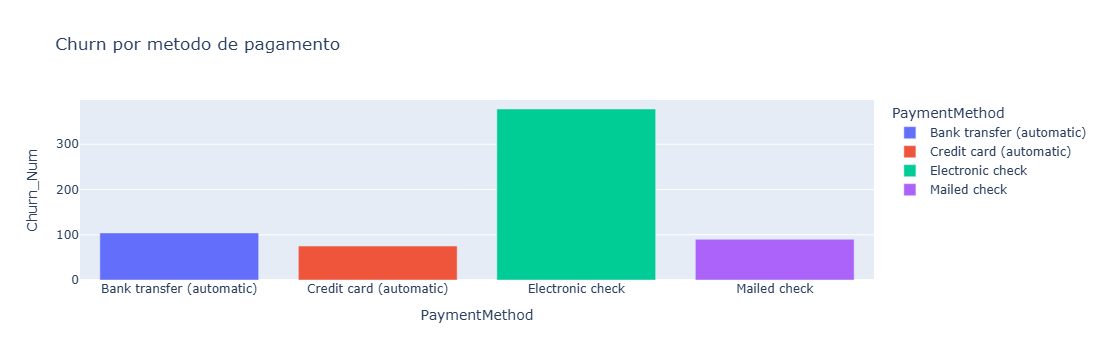

In [20]:
churn_method = df.groupby('PaymentMethod')['Churn_Num'].sum().reset_index()

fig = px.bar(data_frame = churn_method, x = 'PaymentMethod', y ='Churn_Num',
             title = 'Churn por metodo de pagamento',
             color='PaymentMethod')
fig.show()

- Insight: percebemos que clientes com o metodo de pagamento eletronic check possui o maior numero de churn

B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

- a Variavel Contract_type é uma das mais importantes pois com ela conseguimos atingir a maior parte do clientes que estão propomsos aos churn, o que pode tornar as ações tomadas mais efetivas.
- as variaveis de produtos oferecidos são interessantes de se analisar mais a fundo para saber o motivo dos clientes que adquiriam somente 2 e três produtos, e saber quais serviços possuem a maior taxa, assim indicando possibilidades de melhorias de valores ou de serviços dependendo dos dados analisados.
- a variavel de time_as_cliente, é importante para prever copmportamentos dos clientes e saber em qual momento é uma boa hora de fazer ações, sem desperdiçar. 